## Spatial region identification in the human breast cancer data analysis

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import umap
import os
import scipy.sparse
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import INSPIRE

import warnings
warnings.filterwarnings("ignore")

### Load results

In [2]:
res_path = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tutorials/new_examples/human_breast_cancer_xenium"
adata_full = sc.read_h5ad(res_path + "/adata_inspire.h5ad")

### Spatial region identification

In [3]:
# clustering
sc.pp.neighbors(adata_full, use_rep="latent", n_neighbors=15)
sc.tl.louvain(adata_full, resolution=1.)

In [4]:
adata_full.write(res_path + "/adata_inspire_with_louvain.h5ad")

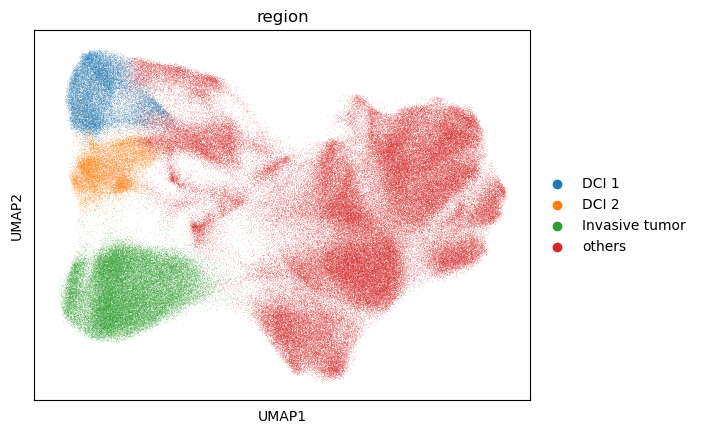

In [5]:
adata = sc.read_h5ad(res_path + "/adata_inspire_with_louvain.h5ad")
adata.obsm["factors"] = np.array(adata.obs[["Proportion of spatial factor "+str(j+1) for j in range(50)]].values)

adata.obs["region"] = "others"
adata.obs["region"][adata.obs["louvain"].values.astype(str) == "2"] = "DCI 1"
adata.obs["region"][adata.obs["louvain"].values.astype(str) == "8"] = "DCI 2"
adata.obs["region"][adata.obs["louvain"].values.astype(str) == "0"] = "Invasive tumor"

sc.pl.umap(adata, color="region")

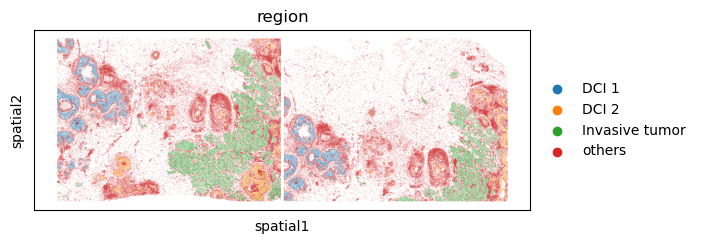

In [6]:
sc.pl.spatial(adata, color="region", spot_size=10.)

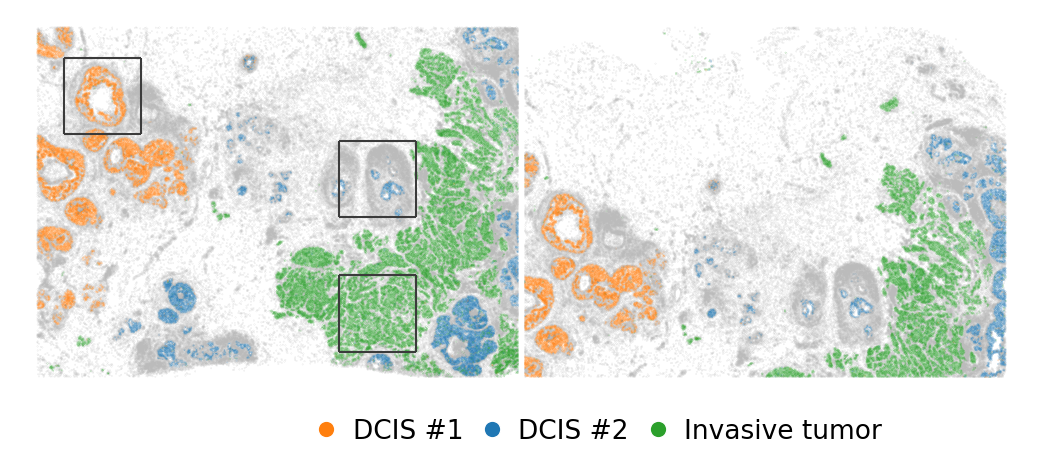

In [7]:
xmin_r1, xmax_r1, ymin_r1, ymax_r1 = -7100, -5900, 3800, 5000
xmin_r2, xmax_r2, ymin_r2, ymax_r2 = -2800, -1600, 2500, 3700
xmin_r3, xmax_r3, ymin_r3, ymax_r3 = -2800, -1600, 400, 1600

from matplotlib.lines import Line2D

f = plt.figure(figsize=(13.2,5))
ax = f.add_subplot(1,1,1)

x_coor = adata.obsm["spatial"][:, 0]
y_coor = -adata.obsm["spatial"][:, 1]

colors = ["tab:orange", "tab:blue", "tab:green"]
adata.obs["region_color"] = "#bbbbbb"
adata.obs["region_color"][adata.obs["region"].values.astype(str) == "DCI 1"] = colors[0]
adata.obs["region_color"][adata.obs["region"].values.astype(str) == "DCI 2"] = colors[1]
adata.obs["region_color"][adata.obs["region"].values.astype(str) == "Invasive tumor"] = colors[2]

size = 0.01
scatter0 = ax.scatter(x_coor, y_coor, s=size, rasterized=True, color=adata.obs["region_color"])

plt.hlines(y=ymin_r1, xmin=xmin_r1, xmax=xmax_r1, linewidth=1.5, color='#3b3b3b', linestyles="-")
plt.hlines(y=ymax_r1, xmin=xmin_r1, xmax=xmax_r1, linewidth=1.5, color='#3b3b3b', linestyles="-")
plt.vlines(x=xmin_r1, ymin=ymin_r1, ymax=ymax_r1, linewidth=1.5, color='#3b3b3b', linestyles="-")
plt.vlines(x=xmax_r1, ymin=ymin_r1, ymax=ymax_r1, linewidth=1.5, color='#3b3b3b', linestyles="-")

plt.hlines(y=ymin_r2, xmin=xmin_r2, xmax=xmax_r2, linewidth=1.5, color='#3b3b3b', linestyles="-")
plt.hlines(y=ymax_r2, xmin=xmin_r2, xmax=xmax_r2, linewidth=1.5, color='#3b3b3b', linestyles="-")
plt.vlines(x=xmin_r2, ymin=ymin_r2, ymax=ymax_r2, linewidth=1.5, color='#3b3b3b', linestyles="-")
plt.vlines(x=xmax_r2, ymin=ymin_r2, ymax=ymax_r2, linewidth=1.5, color='#3b3b3b', linestyles="-")

plt.hlines(y=ymin_r3, xmin=xmin_r3, xmax=xmax_r3, linewidth=1.5, color='#3b3b3b', linestyles="-")
plt.hlines(y=ymax_r3, xmin=xmin_r3, xmax=xmax_r3, linewidth=1.5, color='#3b3b3b', linestyles="-")
plt.vlines(x=xmin_r3, ymin=ymin_r3, ymax=ymax_r3, linewidth=1.5, color='#3b3b3b', linestyles="-")
plt.vlines(x=xmax_r3, ymin=ymin_r3, ymax=ymax_r3, linewidth=1.5, color='#3b3b3b', linestyles="-")

ax.axis('equal')

ax = plt.gca()
ax.set_axis_off()

legend_elements_layer = [Line2D([0], [0], marker='o', color="w", label="DCIS #1", markerfacecolor=colors[0], markersize=8),
                         Line2D([0], [0], marker='o', color="w", label="DCIS #2", markerfacecolor=colors[1], markersize=8),
                         Line2D([0], [0], marker='o', color="w", label="Invasive tumor", markerfacecolor=colors[2], markersize=8)]
ax.legend(handles=legend_elements_layer, loc="upper left", bbox_to_anchor=(0.26, 0.), frameon=False, 
          markerscale=1.5, fontsize=19, handletextpad=0., ncol=3, columnspacing=0.1)

plt.show()

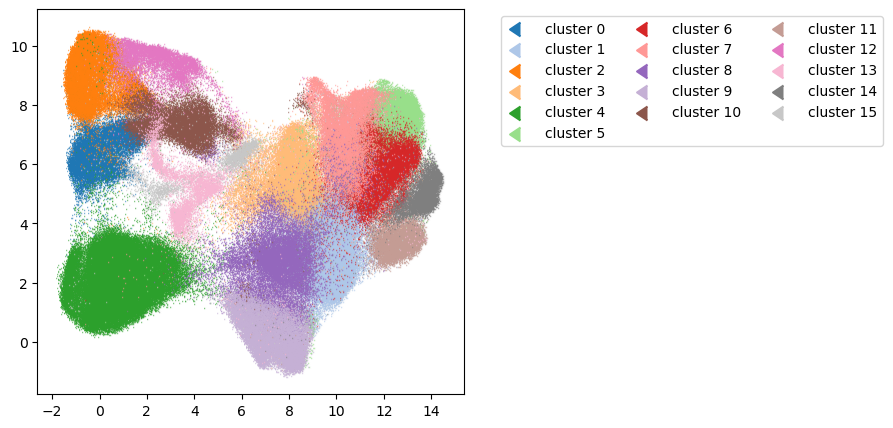

In [8]:
adata = sc.read_h5ad(res_path + "/adata_inspire_with_louvain.h5ad")

adata.obs["louvain"] = adata.obs["louvain"].values.astype(str)
adata.obs["louvain"][adata.obs["louvain"] == "8"] = "aa"
adata.obs["louvain"][adata.obs["louvain"] == "0"] = "8"
adata.obs["louvain"][adata.obs["louvain"] == "aa"] = "0"
adata.obs["louvain"] = adata.obs["louvain"].values.astype(int)

adata.obs["louvain"] = adata.obs["louvain"].values.astype(str)
adata.obs["louvain"][adata.obs["louvain"] == "8"] = "aa"
adata.obs["louvain"][adata.obs["louvain"] == "4"] = "8"
adata.obs["louvain"][adata.obs["louvain"] == "aa"] = "4"
adata.obs["louvain"] = adata.obs["louvain"].values.astype(int)


from matplotlib.cm import get_cmap
import matplotlib as mpl

# visualize umaps
size = .01

rgb_10 = [i for i in get_cmap('Set3').colors]
rgb_20 = [i for i in get_cmap('tab20').colors]
rgb_20b = [i for i in get_cmap('tab20b').colors]
rgb_dark2 = [i for i in get_cmap('Dark2').colors]
rgb_pst1 = [i for i in get_cmap('Pastel1').colors]
rgb_acc = [i for i in get_cmap('Accent').colors]
rgb2hex_10 = [mpl.colors.rgb2hex(color) for color in rgb_10]
rgb2hex_20 = [mpl.colors.rgb2hex(color) for color in rgb_20]
rgb2hex_20b = [mpl.colors.rgb2hex(color) for color in rgb_20b]
rgb2hex_20b_new = [rgb2hex_20b[i] for i in [0, 3, 4, 7, 8, 11, 12, 15, 16, 19]]
rgb2hex_dark2 = [mpl.colors.rgb2hex(color) for color in rgb_dark2]
rgb2hex_pst1 = [mpl.colors.rgb2hex(color) for color in rgb_pst1]
rgb2hex_acc = [mpl.colors.rgb2hex(color) for color in rgb_acc]
rgb2hex = rgb2hex_20 + rgb2hex_20b_new + rgb2hex_dark2 + rgb2hex_pst1 + rgb2hex_acc


embedding = adata.obsm["X_umap"]

# umap, louvain
f = plt.figure(figsize=(5.5,5))
ax = f.add_subplot(1,1,1)
n_louvain = len(set(adata.obs["louvain"]))
colors = rgb2hex
for i in range(n_louvain):
    ax.scatter(embedding[adata.obs["louvain"].values.astype(str)==str(i), 0], 
               embedding[adata.obs["louvain"].values.astype(str)==str(i), 1], 
               s=size, c=colors[i], label="cluster "+str(i), rasterized=True, marker=8)
plt.legend(markerscale=100, ncol=3, bbox_to_anchor=(2,1))
plt.show()

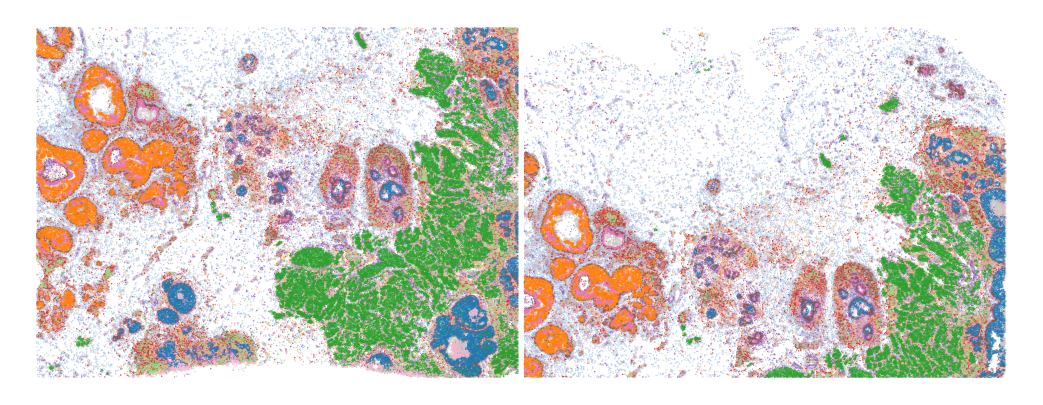

In [9]:
colors = rgb2hex
adata.obs["cluster_color"] = ""
for i in range(n_louvain):
    adata.obs["cluster_color"][adata.obs["louvain"].values.astype(str) == str(i)] = colors[i]

f = plt.figure(figsize=(13.2,5))
ax = f.add_subplot(1,1,1)

x_coor = adata.obsm["spatial"][:, 0]
y_coor = -adata.obsm["spatial"][:, 1]

size = 0.001
scatter0 = ax.scatter(x_coor, y_coor, s=size, rasterized=True, color=adata.obs["cluster_color"], marker=8)

ax.axis('equal')

ax = plt.gca()
ax.set_axis_off()

plt.show()